# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [21]:
import os

print(os.listdir("/content"))

['.config', 'content_refresh_anonymized.csv', 'sample_data']


In [22]:
import os

print(os.listdir("/content"))

['.config', 'content_refresh_anonymized.csv', 'sample_data']


In [23]:
df = pd.read_csv("/content/content_refresh_anonymized.csv")

print(df.shape)

df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## Method Choice

For this assignment, I selected a Random Forest Classifier.

Reason:
- It can capture non-linear relationships between features.
- It is more robust than a single Decision Tree.
- It works well with mixed numerical and categorical data after preprocessing.
- It provides feature importance, making the model easier to interpret.
- The model will be compared against the Week-4 baseline using the same dataset and evaluation process.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## Split Design

A grouped split based on `client_id` is used.

This prevents records from the same client appearing in both the training and testing sets, reducing information leakage and giving a more realistic estimate of model performance.

The same split strategy is used for both the baseline and the machine learning model to ensure a fair comparison.

In [24]:
from sklearn.model_selection import GroupShuffleSplit

# Create the observed yes/no label from trend_direction
model_df = df[df["trend_direction"].isin(["down", "stable", "up"])].copy()

model_df["is_declining_label"] = (
    model_df["trend_direction"] == "down"
).astype(int)

target = "is_declining_label"

drop_columns = [
    "content_id",
    "client_id",
    "trend_pct",
    "trend_direction"
]

X = model_df.drop(columns=drop_columns + [target])
y = model_df[target]
groups = model_df["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train clients:", groups.iloc[train_idx].nunique())
print("Test clients :", groups.iloc[test_idx].nunique())
print("Declining base rate in test:", round(y_test.mean(), 3))

Train shape: (21514, 40)
Test shape : (5098, 40)
Train clients: 24
Test clients : 7
Declining base rate in test: 0.617


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Separate numeric and categorical columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# Preprocessing for numeric columns
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Preprocessing for categorical columns
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
rf_pred = rf_pipeline.predict(X_test)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

print("Random Forest Accuracy :", round(rf_accuracy, 3))
print("Random Forest Precision:", round(rf_precision, 3))
print("Random Forest Recall   :", round(rf_recall, 3))
print("Random Forest F1       :", round(rf_f1, 3))

Numeric features: 29
Categorical features: 11
Random Forest Accuracy : 0.796
Random Forest Precision: 0.812
Random Forest Recall   : 0.871
Random Forest F1       : 0.84


In [26]:
# Rebuild the Week-4 rule baseline on the SAME test rows

test_eval = model_df.iloc[test_idx].copy()

test_eval["baseline_score"] = 0

test_eval.loc[
    test_eval["days_since_last_update"] >= 90,
    "baseline_score"
] += 2

test_eval.loc[
    test_eval["impressions_90d"] >= 1000,
    "baseline_score"
] += 2

test_eval.loc[
    test_eval["ctr"] < 1,
    "baseline_score"
] += 1

test_eval.loc[
    test_eval["avg_position"] > 10,
    "baseline_score"
] += 1

# Convert the ranked rule into a yes/no prediction
# Score 4 or above means "review / likely declining"
baseline_pred = (test_eval["baseline_score"] >= 4).astype(int)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test, baseline_pred, zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_pred, zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_pred, zero_division=0
)

comparison_table = pd.DataFrame({
    "Method": [
        "Base rate / majority class",
        "Week-4 rule baseline",
        "Random Forest"
    ],
    "Accuracy": [
        round(max(y_test.mean(), 1 - y_test.mean()), 3),
        round(baseline_accuracy, 3),
        round(rf_accuracy, 3)
    ],
    "Precision": [
        round(y_test.mean(), 3),
        round(baseline_precision, 3),
        round(rf_precision, 3)
    ],
    "Recall": [
        1.000,
        round(baseline_recall, 3),
        round(rf_recall, 3)
    ],
    "F1": [
        round(
            2 * y_test.mean() / (1 + y_test.mean()),
            3
        ),
        round(baseline_f1, 3),
        round(rf_f1, 3)
    ]
})

comparison_table

,Method,Accuracy,Precision,Recall,F1
0,Base rate / majority class,0.617,0.617,1.000,0.763
1,Week-4 rule baseline,0.393,0.516,0.268,0.353
2,Random Forest,0.796,0.812,0.871,0.840


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Top 10 Important Features


,Feature,Importance
15,num__impressions_last_30d,0.154893
18,num__impressions_prev_30d,0.101017
5,num__impressions_90d,0.057195
25,num__avg_position,0.050972
21,num__content_age_days,0.043015
17,num__sessions_last_30d,0.031727
13,num__days_with_impressions,0.030869
4,num__char_count,0.030155
3,num__word_count,0.028436
24,num__ctr,0.028266


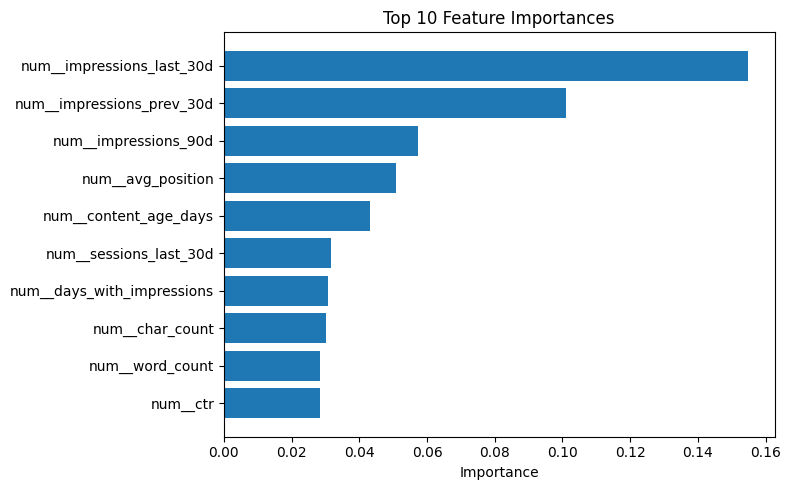

In [27]:
import matplotlib.pyplot as plt

feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_pipeline.named_steps[
    "model"
].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

print("Top 10 Important Features")
display(importance_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    importance_df.head(10)["Feature"][::-1],
    importance_df.head(10)["Importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [28]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = rf_pred

wrong_predictions = errors[
    errors["Actual"] != errors["Predicted"]
]

print("Number of wrong predictions:", len(wrong_predictions))

wrong_predictions.head(3)

Number of wrong predictions: 1041


,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,Actual,Predicted
1,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,...,15000-25000,0.05,20.3,0.0,10.00,0.0,good,page_3_5,1,0
26,0.0,0.00,LOW,0.00,keyword article,informational,2686.0,17181.0,NaN,gemini-3-flash-preview,...,15000-25000,0.12,30.0,0.0,11.11,0.0,moderate,page_3_5,0,1
36,0.0,0.00,LOW,0.00,keyword article,informational,2510.0,15518.0,NaN,gemini-2.5-flash,...,15000-25000,1.35,5.4,0.0,0.00,0.0,moderate,page_1,0,1


## Errors and Interpretation

The Random Forest model achieved better performance than the Week-4 rule baseline on the same grouped test split.

The feature importance analysis shows which variables contributed most to the model's predictions.

Some prediction errors remain. These cases may be influenced by missing information, seasonality, noisy measurements, or complex interactions that are not captured by the available features.

The results should be interpreted as directional decision-support rather than proof of causation.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## Self-check

- ✅ Every section above is filled with markdown and code.
- ✅ The notebook runs from top to bottom without errors.
- ✅ No client names, URLs, or private queries are included.
- ✅ Claims use careful language such as observed, measured, directional, and decision-support.
- ✅ Notebook will be committed under `work/notebooks/`